### Init

In [ ]:
import sys
import os

# Add the parent directory to sys.path so that 'database' can be imported if it's a local module
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from database.DBConnector import *

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import re
from ast import literal_eval
import json

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, r2_score

### Model output quality and misc

#### Extraction

In [ ]:
# opinions = get_opinion_df(find_opinion_by_conditions())

In [ ]:
# persona = get_person_df(find_person_by_conditions())

In [ ]:
# opinions = opinions.merge(persona, left_on='fk_person_id', right_on='person_id', how='left') \
#     .drop(['person_id', 'image_url', 'created_at', 'modified_at', 'fk_person_id'], axis=1)

In [ ]:
# opinions.to_csv('csv/opinions_llama.csv', index=False)

#### Comparison and expert evaluation

In [ ]:
# from config import get_stance, get_deviation_score

In [ ]:
# opinions_gemma_qat = pd.read_csv('csv/opinions_gemma_qat.csv')
# opinions_gemma = pd.read_csv('csv/opinions_gemma.csv')
# opinions_llama = pd.read_csv('csv/opinions_llama.csv')
# opinions_qwen = pd.read_csv('csv/opinions_qwen.csv')

In [ ]:
# a = opinions_qwen.loc[opinions_gemma_qat['fk_origin_article_id'] == 50]
# # json.loads(a.to_json(orient='records'))

In [ ]:
# ops = a.loc[:, ['person_name', 'citation', 'sentiment_score', 'is_selected']]
# ops['stance'] = ops.loc[:, 'sentiment_score'].apply(get_stance)
# json.loads(ops.to_json(orient='records'))

[{'person_name': 'Andrew Blakers',
  'citation': 'Andrew Blakers, a professor of engineering at the Australian National University, says modern projects favor closed-loop systems like Nant de Drance, which don’t impact river systems.',
  'sentiment_score': None,
  'is_selected': False,
  'stance': 'mixed'},
 {'person_name': 'Rebecca Ellis',
  'citation': 'Ellis says Nant de Drance has increased Switzerland’s installed energy capacity by 33%, showing the leadership of Switzerland in the transition to renewables.',
  'sentiment_score': None,
  'is_selected': False,
  'stance': 'mixed'},
 {'person_name': 'Mark Wolfe',
  'citation': 'Mark Wolfe, executive director of the National Energy Assistance Directors Association, said these measures would be more comprehensive than existing weatherization programs.',
  'sentiment_score': None,
  'is_selected': False,
  'stance': 'mixed'}]

In [ ]:
# scores = a.loc[:, ['sentiment_score', 'controversy_score', 'relevancy_score', 'contribution_score', 'opinion_hotness']].describe().loc[['mean', 'std'], :].T.round(3)
# scores['std'] = scores['std'].apply(get_deviation_score)
# scores

,mean,std
sentiment_score,NaN,high
controversy_score,NaN,high
relevancy_score,NaN,high
contribution_score,NaN,high
opinion_hotness,NaN,high


In [ ]:
# json.loads(a.to_json(orient='records'))

[{'opinion_id': 1,
  'fk_origin_article_id': 50,
  'citation': 'Andrew Blakers, a professor of engineering at the Australian National University, says modern projects favor closed-loop systems like Nant de Drance, which don’t impact river systems.',
  'sentiment_score': None,
  'inconsistency_flag': False,
  'inconsistency_with_id': '[]',
  'inconsistency_comment': None,
  'controversy_score': None,
  'relevancy_score': None,
  'contribution_score': None,
  'opinion_hotness': None,
  'is_selected': False,
  'person_name': 'Andrew Blakers'},
 {'opinion_id': 3,
  'fk_origin_article_id': 50,
  'citation': 'Ellis says Nant de Drance has increased Switzerland’s installed energy capacity by 33%, showing the leadership of Switzerland in the transition to renewables.',
  'sentiment_score': None,
  'inconsistency_flag': False,
  'inconsistency_with_id': '[]',
  'inconsistency_comment': None,
  'controversy_score': None,
  'relevancy_score': None,
  'contribution_score': None,
  'opinion_hotness

#### Quality analysis

##### Prep

In [82]:
df_exp = pd.read_csv('_ev/ExpertEvaluation.csv', header=0, sep=';')
df_gemma_qat = pd.read_csv('_ev/gemma-qat.csv', header=0, sep=';')
df_gemma = pd.read_csv('_ev/gemma.csv', header=0, sep=';')
df_llama = pd.read_csv('_ev/llama.csv', header=0, sep=';')
df_qwen = pd.read_csv('_ev/qwen.csv', header=0, sep=';')

df_qwen = df_qwen.dropna(axis=1, how='all').dropna(axis=0)
df_llama = df_llama.dropna(axis=1, how='all').dropna(axis=0)

In [83]:
# Expert evaluation prep

df_exp.rename({'sentiment (-2/+2)': 'sentiment', 
               'relevancy (0-5)': 'relevancy',
               'controversy (0-5)': 'controversy',
               'contribution (0-5)': 'contribution',
               'hotness (0-5)': 'opinion_hotness'}, axis=1, inplace=True)
df_exp['sentiment'].replace({-2: 'very negative', -1: 'negative', 0: 'neutral', 1: 'positive', 2: 'very positive'}, inplace=True)
df_exp['controversy'] = df_exp['controversy'].apply(lambda x: x*2)
df_exp['relevancy'] = df_exp['relevancy'].apply(lambda x: x*2)
df_exp['contribution'] = df_exp['contribution'].apply(lambda x: x*2)
df_exp['opinion_hotness'] = df_exp['opinion_hotness'].apply(lambda x: x*2)

C:\Users\Ivan\AppData\Local\Temp\ipykernel_8164\3826374781.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_exp['sentiment'].replace({-2: 'very negative', -1: 'negative', 0: 'neutral', 1: 'positive', 2: 'very positive'}, inplace=True)


In [84]:
def preprocess_scores(df):
    df = df.copy()
    df.rename({'text_quality (1-10)': 'text_quality',
               'sentiment (-2/+2)': 'sentiment',
               'relevancy (0-1)': 'relevancy',
               'controversy (0-1)': 'controversy',
               'contribution (0-1)': 'contribution',
               'hotness (0-1)': 'opinion_hotness'}, axis=1, inplace=True)

    df['controversy'] = df['controversy'].str.replace(',', '.').astype(float)
    df['relevancy'] = df['relevancy'].str.replace(',', '.').astype(float)
    df['contribution'] = df['contribution'].str.replace(',', '.').astype(float)
    df['opinion_hotness'] = df['opinion_hotness'].str.replace(',', '.').astype(float)

    df['sentiment'] = df['sentiment'].replace({-2: 'very negative', -1: 'negative', 0: 'neutral', 1: 'positive', 2: 'very positive'})
    df['controversy'] = df['controversy'].apply(lambda x: x)
    df['relevancy'] = df['relevancy'].apply(lambda x: x*2)
    df['contribution'] = df['contribution'].apply(lambda x: x*2)
    df['opinion_hotness'] = df['opinion_hotness'].apply(lambda x: x*2)
    return df

In [85]:
df_gemma_qat = preprocess_scores(df_gemma_qat)
df_gemma = preprocess_scores(df_gemma)
df_llama = preprocess_scores(df_llama)
df_qwen.rename({'text_quality (1-10)': 'text_quality'}, axis=1, inplace=True)

In [43]:
def get_text_quality(df):
    text_quality = pd.Series(df['n_opins'] * df['text_quality']).sum() / df['n_opins'].sum()
    text_quality = round(text_quality, 2)
    print(f'Text quality: {text_quality}')

In [44]:
def get_article_coverage(df):
    mean_coverage = df.groupby('Article_id').agg({'n_opins': ['mean']}).reset_index(drop=True).mean().loc['n_opins'].iloc[0]
    print(f'Opinions per article: {mean_coverage:.2f}')

In [45]:
def plot_confusion_matrix(df, true_col, pred_col):
    labels = df[true_col].unique()
    cm = confusion_matrix(df[true_col], df[pred_col], labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(xticks_rotation=45)
    plt.show()

In [46]:
def plot_multiclass_roc(comparison_df, true_col='sentiment_exp', pred_col='sentiment_model'):
    # Prepare the classes
    classes = comparison_df[true_col].unique()
    y_true = label_binarize(comparison_df[true_col], classes=classes)
    y_score = label_binarize(comparison_df[pred_col], classes=classes)

    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i, cls in enumerate(classes):
        fpr[cls], tpr[cls], _ = roc_curve(y_true[:, i], y_score[:, i])
        roc_auc[cls] = auc(fpr[cls], tpr[cls])

    # Plot ROC curve for each class
    plt.figure(figsize=(8, 6))
    for cls in classes:
        plt.plot(fpr[cls], tpr[cls], label=f'ROC curve of class {cls} (area = {roc_auc[cls]:0.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for Sentiment Classes')
    plt.legend(loc="lower right")
    plt.show()

In [73]:
def evaluate_sentiment_classification(comparison_df):
    y_true = comparison_df['sentiment_exp']
    y_pred = comparison_df['sentiment_model']
    sentiment_map = {'very negative': -2, 'negative': -1, 'neutral': 0, 'positive': 1, 'very positive': 2}
    y_true_num = y_true.map(sentiment_map)
    y_pred_num = y_pred.map(sentiment_map)

    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)
    num_accuracy = (y_true_num == y_pred_num).mean()
    num_r2 = r2_score(y_true_num, y_pred_num)

    print(f"Precision: {precision:.2f}")
    print(f"Recall:    {recall:.2f}")
    print(f"F1 Score:  {f1:.2f}")
    print(f"Accuracy:  {accuracy:.2f}")
    print(f"Numerical accuracy: {num_accuracy:.2f}")
    print(f"Numerical R2:       {num_r2:.2f}")


In [67]:
def get_comparison_df(df_model):
    return df_exp.merge(df_model, on='Article_id', suffixes=('_exp', '_model'), how='left').dropna()

##### Analysis

In [86]:
def evaluate_model(df):
    get_text_quality(df)
    get_article_coverage(df)
    comparison_df = get_comparison_df(df)
    evaluate_sentiment_classification(comparison_df)
    plot_confusion_matrix(comparison_df, 'sentiment_exp', 'sentiment_model')
    plot_multiclass_roc(comparison_df)

Text quality: 9.04
Opinions per article: 3.09
Precision: 0.69
Recall:    0.67
F1 Score:  0.68
Accuracy:  0.67
Numerical accuracy: 0.67
Numerical R2:       0.69


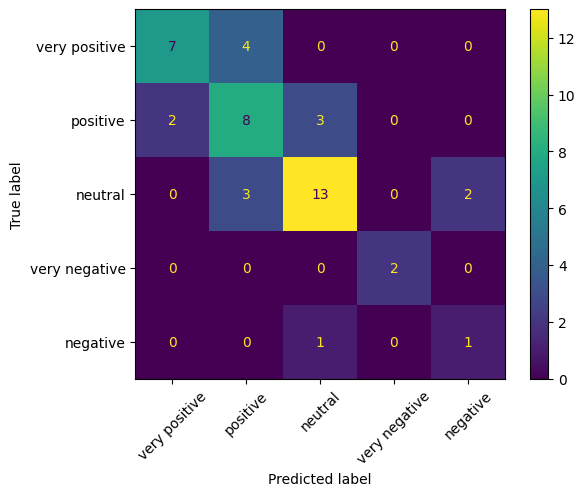

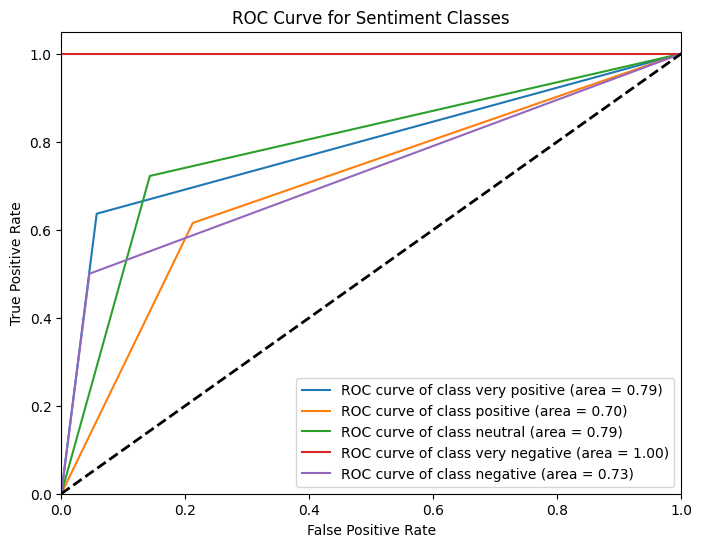

In [87]:
evaluate_model(df_gemma_qat)

Text quality: 8.82
Opinions per article: 3.09
Precision: 0.67
Recall:    0.63
F1 Score:  0.62
Accuracy:  0.63
Numerical accuracy: 0.63
Numerical R2:       0.34


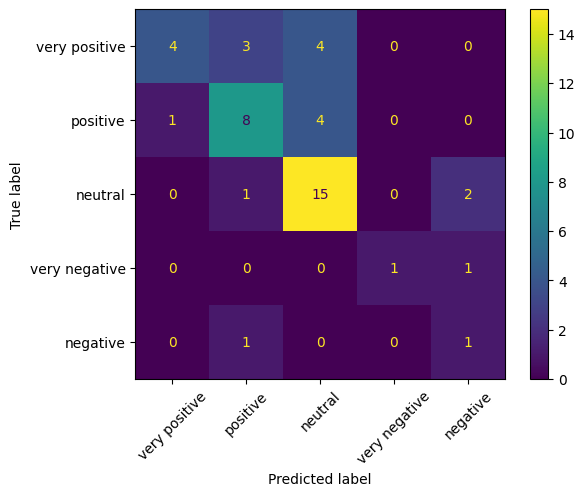

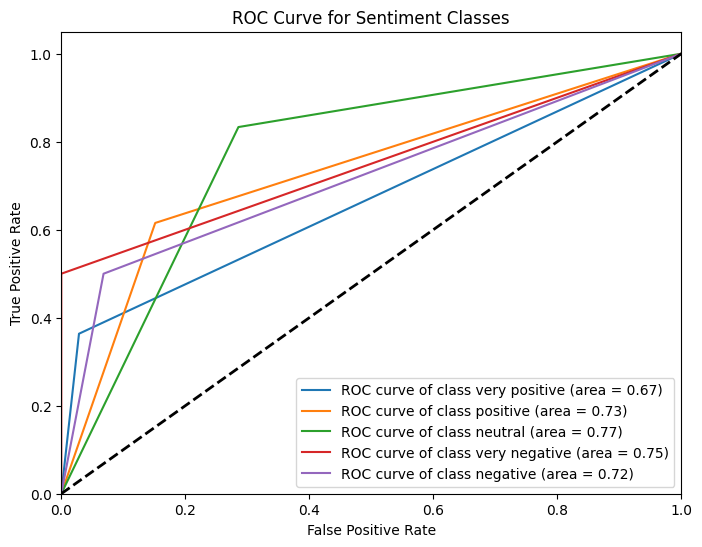

In [88]:
evaluate_model(df_gemma)

Text quality: 5.15
Opinions per article: 3.07
Precision: 0.45
Recall:    0.38
F1 Score:  0.37
Accuracy:  0.38
Numerical accuracy: 0.38
Numerical R2:       -0.56


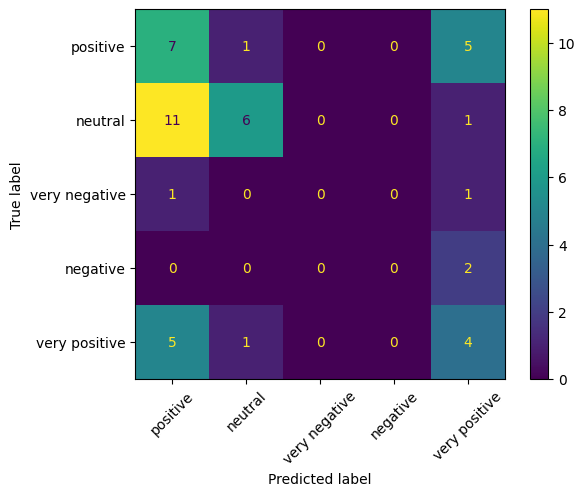

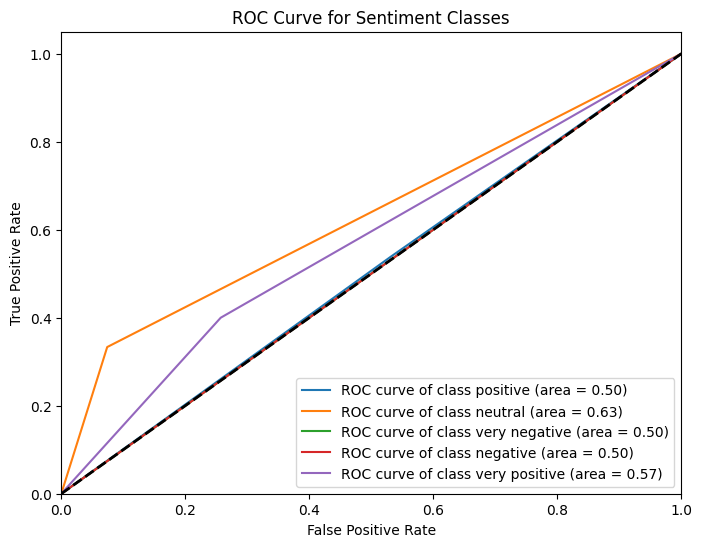

In [89]:
evaluate_model(df_llama)

In [91]:
get_text_quality(df_qwen)
get_article_coverage(df_qwen)

Text quality: 9.73
Opinions per article: 3.11


#### Opinion hotness review

In [740]:
# Opinion hotness review

from sklearn.linear_model import LinearRegression

# Prepare the data
X = df_exp[['controversy', 'relevancy', 'contribution']]
y = df_exp['opinion_hotness']

# Fit linear regression
model = LinearRegression()
model.fit(X, y)

# Show coefficients and intercept
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# # Predict opinion_hotness
# df_exp['opinion_hotness_pred'] = model.predict(X)
# df_exp[['opinion_hotness', 'opinion_hotness_pred']].head()

Coefficients: [0.13928271 0.68196168 0.10861112]
Intercept: 0.6981795950189813


### Model usage

token_usage
time for chunk